In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import io

In [95]:
df = pd.read_excel(r'C:\Users\Lakshya\Adult_Income_Census\adult.xlsx', na_values="?")

In [96]:
#Replacing missing values "?" to "NaN":
df.replace("?", pd.NA, inplace=True)

In [97]:
df.head(50)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


**<h1 style="font-size: 30px;">Some Opeartions with Numpy</h1>**

**Convert the age column to a NumPy array and compute basic statistics**

In [98]:
# Mean, Median, Std
ages = df['age'].to_numpy()

print("Mean:", np.mean(ages))
print("Median:", np.median(ages))
print("Std:", np.std(ages))

Mean: 38.58164675532078
Median: 37.0
Std: 13.640223092304277


**Find the percentage of people earning >50K using NumPy**

In [99]:
income = df['income'].to_numpy()

high_income_ratio = np.mean(income == '>50K')
print("Percentage earning >50K:", high_income_ratio * 100)

Percentage earning >50K: 24.080955744602438


**Normalize hours.per.week using Min–Max normalization**

In [100]:
hours = df['hours.per.week'].to_numpy()

normalized_hours = (hours - hours.min()) / (hours.max() - hours.min())

#Printing head 10 only:
print(normalized_hours[:10])

[0.39795918 0.17346939 0.39795918 0.39795918 0.39795918 0.44897959
 0.39795918 0.19387755 0.39795918 0.60204082]


**Detect outliers in capital.gain using Z-score**

In [101]:
capital_gain = df['capital.gain'].to_numpy()

z_scores = (capital_gain - capital_gain.mean()) / capital_gain.std()
outliers = capital_gain[np.abs(z_scores) > 3]

#Printing head 10 only:
print("Outliers:", outliers[:10])

Outliers: [99999 99999 99999 99999 99999 99999 99999 99999 99999 99999]


**Compute correlation between age and hours.per.week**

In [102]:
age = df['age'].to_numpy()
hours = df['hours.per.week'].to_numpy()

correlation = np.corrcoef(age, hours)[0, 1]
print("Correlation:", correlation)

Correlation: 0.06875570750955735


**Create a NumPy mask to filter people working more than 40 hours**

In [103]:
mask = df['hours.per.week'].to_numpy() > 40
filtered_ages = df['age'].to_numpy()[mask]

#Printing head 10 only:
print(filtered_ages[:10])

[34 41 38 32 45 57 34 29 37 38]


**Encode sex column into binary using NumPy**

In [104]:
sex = df['sex'].to_numpy()
encoded_sex = np.where(sex == 'Male', 1, 0)

#Printing head 10 only:
print(encoded_sex[:10])

[0 0 0 0 0 0 1 0 0 1]


**Calculate average age by income group using NumPy only**

In [105]:
ages = df['age'].to_numpy()
income = df['income'].to_numpy()

avg_high = ages[income == '>50K'].mean()
avg_low = ages[income == '<=50K'].mean()

print("Avg age (>50K):", avg_high)
print("Avg age (<=50K):", avg_low)

Avg age (>50K): 44.24984058155847
Avg age (<=50K): 36.78373786407767


**Create a NumPy histogram of education.num**

In [106]:
education_num = df['education.num'].to_numpy()

hist, bins = np.histogram(education_num, bins=10)
print("Histogram:", hist)
print("Bins:", bins)

Histogram: [  219   333  1160   933  1608 10501  8673  1067  7078   989]
Bins: [ 1.   2.5  4.   5.5  7.   8.5 10.  11.5 13.  14.5 16. ]


**Build a NumPy feature matrix (age, hours.per.week, capital.gain)**

In [107]:
features = np.column_stack([
    df['age'].to_numpy(),
    df['hours.per.week'].to_numpy(),
    df['capital.gain'].to_numpy()
])

print(features.shape)
#Head -> 5:
print(features[:5])

(32561, 3)
[[90 40  0]
 [82 18  0]
 [66 40  0]
 [54 40  0]
 [41 40  0]]


**<h1 style="font-size: 30px;">Some Opeartions with Pandas</h1>**

**What is the average age by income group?**

In [108]:
df.groupby('income')['age'].mean()

income
<=50K    36.783738
>50K     44.249841
Name: age, dtype: float64

**Which occupation has the highest average salary rate (>50K percentage)?**

In [109]:
result = (
    df.groupby('occupation')['income']
      .apply(lambda x: (x == '>50K').mean())
      .sort_values(ascending=False)
)

print(result.head())

occupation
Exec-managerial    0.484014
Prof-specialty     0.449034
Protective-serv    0.325116
Tech-support       0.304957
Sales              0.269315
Name: income, dtype: float64


**Count number of people per education level**

In [110]:
df['education'].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

**What percentage of males earn >50K?**

In [111]:
male_high_income = df[df['sex'] == 'Male']
percentage = (male_high_income['income'] == '>50K').mean() * 100

print(percentage)

30.573657641119777


**Find correlation between numerical features**

In [112]:
df.corr(numeric_only=True)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


**Create a new column: income_binary (1 = >50K, 0 = <=50K)**

In [113]:
df['income_binary'] = df['income'].map({'>50K': 1, '<=50K': 0})

**What is the average hours worked per week by marital status?**

In [114]:
df.groupby('marital.status')['hours.per.week'].mean()

marital.status
Divorced                 41.246680
Married-AF-spouse        41.130435
Married-civ-spouse       43.284856
Married-spouse-absent    39.669856
Never-married            36.939998
Separated                39.301463
Widowed                  32.979859
Name: hours.per.week, dtype: float64

**Find top 5 oldest people in the dataset**

In [115]:
df.sort_values('age', ascending=False).head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,income_binary
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,0
21192,90,Private,84553,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K,0
3854,90,Local-gov,214594,7th-8th,4,Married-civ-spouse,Protective-serv,Husband,White,Male,2653,0,40,United-States,<=50K,0
2296,90,Private,46786,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,9386,0,15,United-States,>50K,1
2299,90,Private,175491,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,9386,0,50,Ecuador,>50K,1


**Pivot table: average age by sex and income**

In [116]:
pd.pivot_table(
    df,
    values='age',
    index='sex',
    columns='income',
    aggfunc='mean'
)

income,<=50K,>50K
sex,,
Female,36.210801,42.125530
Male,37.147012,44.625788


**Identify the country with highest proportion of >50K earners**

In [117]:
country_income = (
    df.groupby('native.country')['income']
      .apply(lambda x: (x == '>50K').mean())
      .sort_values(ascending=False)
)

print(country_income.head())

native.country
Iran      0.418605
France    0.413793
India     0.400000
Taiwan    0.392157
Japan     0.387097
Name: income, dtype: float64


**<h1 style="font-size:30px">Some Operations with Matplotlib</h1>**

**Plot age distribution (Histogram)**

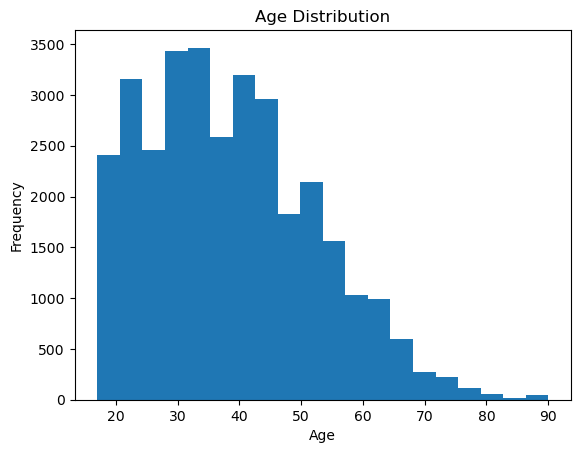

In [118]:
plt.hist(df['age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

**Bar chart of income distribution**

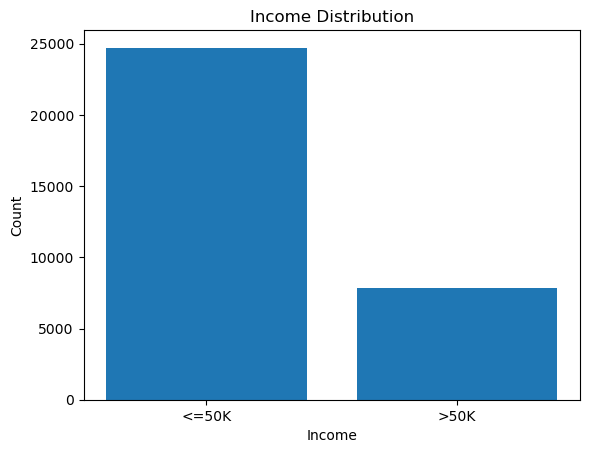

In [119]:
income_counts = df['income'].value_counts()

plt.bar(income_counts.index, income_counts.values)
plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Income Distribution")
plt.show()

**Boxplot of hours.per.week by income group**

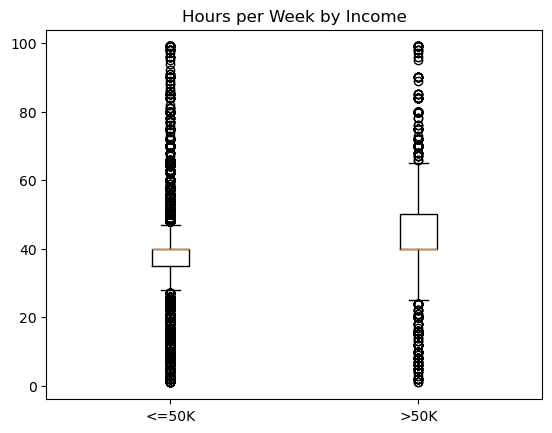

In [120]:
groups = [
    df[df['income'] == '<=50K']['hours.per.week'],
    df[df['income'] == '>50K']['hours.per.week']
]

plt.boxplot(groups, tick_labels=['<=50K', '>50K'])
plt.title("Hours per Week by Income")
plt.show()

**Scatter plot: age vs hours.per.week**

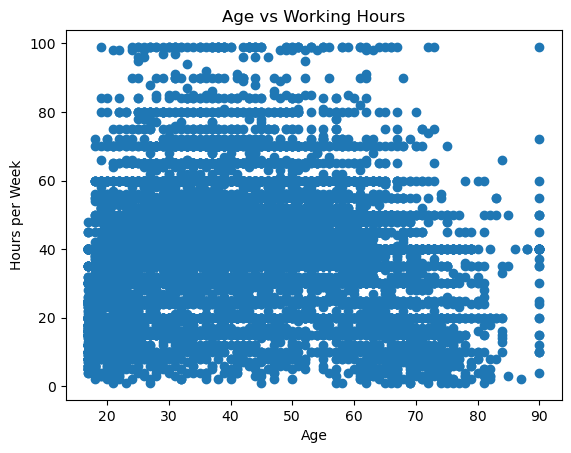

In [121]:
plt.scatter(df['age'], df['hours.per.week'])
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs Working Hours")
plt.show()

**Line plot: Average age by education.num**

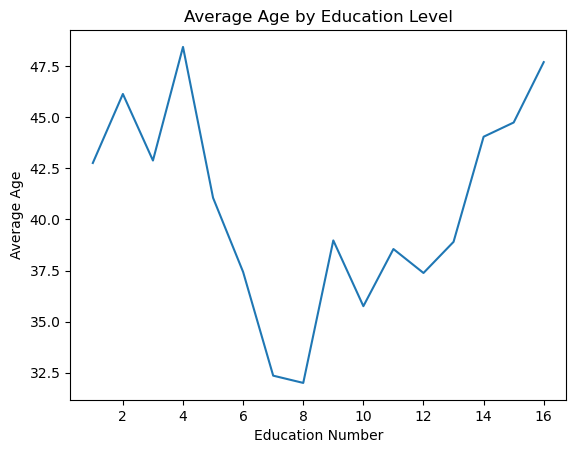

In [122]:
avg_age = df.groupby('education.num')['age'].mean()

plt.plot(avg_age.index, avg_age.values)
plt.xlabel("Education Number")
plt.ylabel("Average Age")
plt.title("Average Age by Education Level")
plt.show()

**Pie chart of gender distribution**

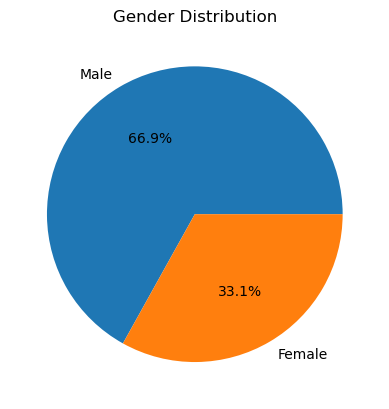

In [123]:
gender_counts = df['sex'].value_counts()

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

**Bar chart: Top 10 occupations**

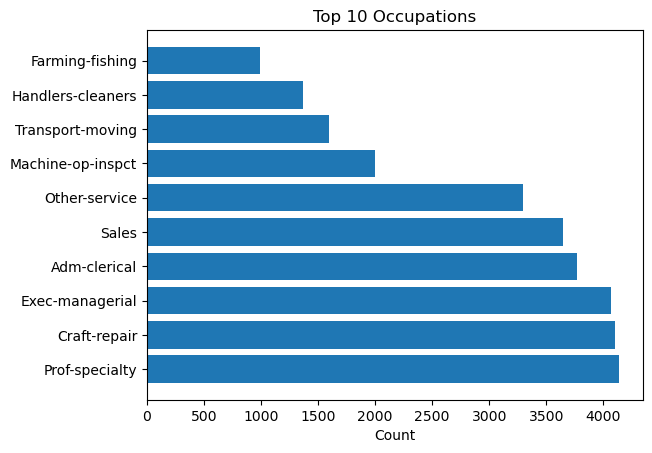

In [124]:
top_occ = df['occupation'].value_counts().head(10)

plt.barh(top_occ.index, top_occ.values)
plt.title("Top 10 Occupations")
plt.xlabel("Count")
plt.show()

**Histogram comparing capital.gain for income groups**

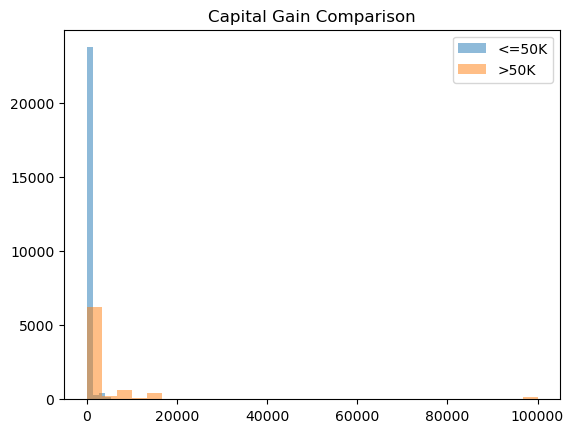

In [125]:
plt.hist(df[df['income'] == '<=50K']['capital.gain'], bins=30, alpha=0.5)
plt.hist(df[df['income'] == '>50K']['capital.gain'], bins=30, alpha=0.5)
plt.legend(['<=50K', '>50K'])
plt.title("Capital Gain Comparison")
plt.show()

**Correlation heatmap (using Matplotlib only)**

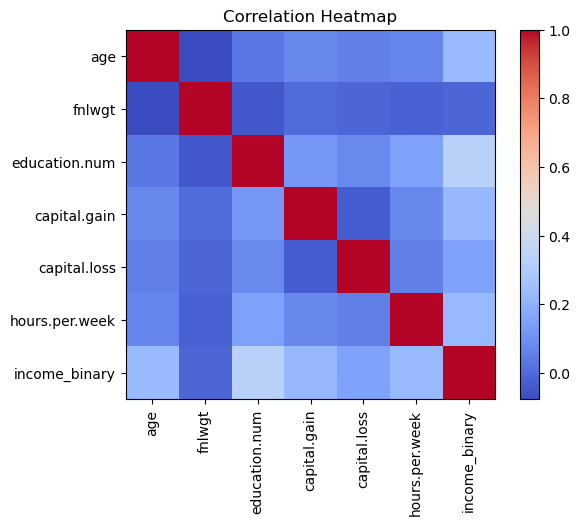

In [126]:
corr = df.corr(numeric_only=True)

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

**Stacked bar chart: Income by sex**

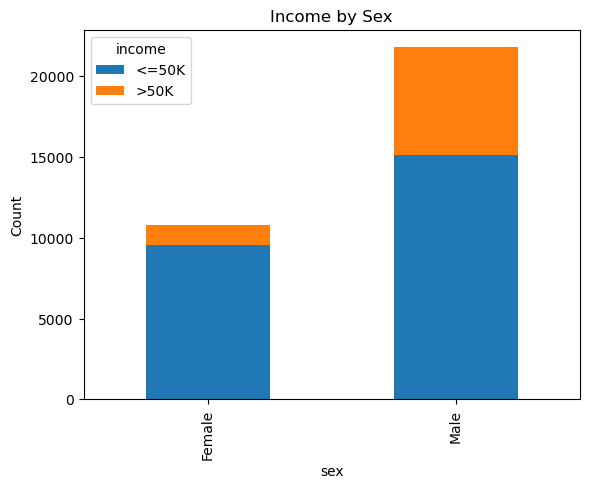

In [127]:
income_sex = pd.crosstab(df['sex'], df['income'])

income_sex.plot(kind='bar', stacked=True)
plt.title("Income by Sex")
plt.ylabel("Count")
plt.show()

**<h1 style="font-size:30px">Dashboard Script</h1>**

In [ ]:
# Census_dashboard_pro.py

# =====================================================
# ---------------- Load & Prepare Data ---------------
# =====================================================

@st.cache_data
def load_data(path=r'C:\Users\Lakshya\Adult_Income_Census\adult.xlsx'):
    df = pd.read_excel(path, na_values="?")

    # Drop missing rows for clean analytics
    df.dropna(inplace=True)

    # Convert numeric columns
    numeric_cols = [
        "age", "fnlwgt", "education.num",
        "capital.gain", "capital.loss", "hours.per.week"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Feature engineering
    df["income_binary"] = df["income"].map({">50K": 1, "<=50K": 0})

    # Age bands
    df["age.band"] = pd.cut(
        df["age"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
    )

    return df


df = load_data()

# =====================================================
# ---------------- Sidebar Filters -------------------
# =====================================================

st.sidebar.header("Filters")

income_option = st.sidebar.selectbox("Income", ["All", "<=50K", ">50K"])
sex_option = st.sidebar.selectbox("Gender", ["All"] + sorted(df["sex"].unique()))

age_min, age_max = int(df["age"].min()), int(df["age"].max())
age_range = st.sidebar.slider("Age Range", age_min, age_max, (25, 60))

# Apply filters
filtered_df = df.copy()

# Create age bands
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ["0-25", "26-35", "36-45", "46-55", "56-65", "65+"]
filtered_df["age_band"] = pd.cut(filtered_df["age"], bins=bins, labels=labels)

if income_option != "All":
    filtered_df = filtered_df[filtered_df["income"] == income_option]

if sex_option != "All":
    filtered_df = filtered_df[filtered_df["sex"] == sex_option]

filtered_df = filtered_df[
    filtered_df["age"].between(age_range[0], age_range[1])
]

# =====================================================
# ---------------- Header & KPIs ---------------------
# =====================================================

st.title("Adult Census — Income Analytics")

total_records = len(filtered_df)
income_rate = filtered_df["income_binary"].mean() * 100 if total_records > 0 else 0
avg_hours = filtered_df["hours.per.week"].mean()
avg_age = filtered_df["age"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Records", total_records)
col2.metric("High Income %", f"{income_rate:.2f}%")
col3.metric("Avg Hours/Week", f"{avg_hours:.2f}")
col4.metric("Avg Age", f"{avg_age:.2f}")

# Download
csv_buffer = io.StringIO()
filtered_df.to_csv(csv_buffer, index=False)
st.download_button("Download CSV",
                   csv_buffer.getvalue(),
                   "filtered_adult.csv",
                   "text/csv")

# =====================================================
# ---------------- Tabs ------------------------------
# =====================================================

tab1, tab2, tab3, tab4 = st.tabs([
    "Demographics",
    "Education & Work",
    "Geographic",
    "Advanced Analytics"
])

# =====================================================
# ---------------- Tab 1: Demographics ---------------
# =====================================================

with tab1:

    st.subheader("Age Distribution")
    fig, ax = plt.subplots()
    ax.hist(filtered_df["age"], bins=20)
    ax.set_xlabel("Age")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Income Probability by Age Band")
    age_income = (
        filtered_df.groupby("age_band", observed=False)["income_binary"]
        .mean()
        .sort_index()
    )

    fig, ax = plt.subplots()
    ax.bar(age_income.index.astype(str), age_income.values)
    ax.set_ylabel("Probability of >50K")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Gender vs Income")
    gender_income = (
        filtered_df.groupby("sex")["income_binary"]
        .mean()
    )
    st.bar_chart(gender_income)

# =====================================================
# ---------------- Tab 2: Education & Work -----------
# =====================================================

with tab2:

    st.subheader("Income Rate by Education Level")
    edu_income = (
        filtered_df.groupby("education")["income_binary"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(edu_income.index, edu_income.values)
    ax.invert_yaxis()
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Income Rate by Occupation")
    occ_income = (
        filtered_df.groupby("occupation")["income_binary"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    st.bar_chart(occ_income)

    st.subheader("Workclass Distribution")
    workclass_counts = filtered_df["workclass"].value_counts()
    st.bar_chart(workclass_counts)

# =====================================================
# ---------------- Tab 3: Geographic ------------------
# =====================================================

with tab3:

    st.subheader("Top Countries by High Income Rate")

    country_income = (
        filtered_df.groupby("native.country")["income_binary"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(country_income.index, country_income.values)
    ax.invert_yaxis()
    st.pyplot(fig)
    plt.close(fig)

# =====================================================
# ---------------- Tab 4: Advanced Analytics ---------
# =====================================================

with tab4:

    st.subheader("Correlation Heatmap")

    numeric_df = filtered_df.select_dtypes(include=np.number)

    if numeric_df.shape[0] > 1:
        corr = numeric_df.corr()

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)
        st.pyplot(fig)
        plt.close(fig)
    else:
        st.info("Not enough numeric data.")

    st.subheader("Age vs Hours Worked")

    fig, ax = plt.subplots()
    ax.scatter(filtered_df["age"],
               filtered_df["hours.per.week"],
               alpha=0.4)
    ax.set_xlabel("Age")
    ax.set_ylabel("Hours per Week")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Statistical Summary")
    st.dataframe(filtered_df.describe())
